In [1]:
#-----Installation des packages et importation des modules------


!pip install yfinance pandas

from datetime import datetime
from functools import reduce
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
import requests
import seaborn as sns
import yfinance as yf

In [2]:
#-----Importation des données------


def get_data_yf(ticker, name, end_date=None):
    """
    Récupère les données historiques OHLCV via YahooFinance.
    end_date: str au format 'YYYY-MM-DD' pour limiter la date maximale
    """
    df = yf.download(ticker, period="max", end=end_date)
    df = df.reset_index()  # remettre la date comme colonne

    df.columns = [col[0] if isinstance(col, tuple) else col for col in df.columns]

    # Renommer les colonnes pour avoir un dataset propre
    df = df.rename(columns={
        "Date": "timestamp",
        "Open": f"{name}_open",
        "High": f"{name}_high",
        "Low": f"{name}_low",
        "Close": f"{name}_price",
        "Volume": f"{name}_volume"
    })

    # On garde uniquement les colonnes utiles
    df = df[["timestamp",
             f"{name}_price",
             f"{name}_volume",
             f"{name}_open",
             f"{name}_high",
             f"{name}_low"]]

    return df

# Date de fin
end_date = "2025-12-22"

# Récupération cryptos
btc_df = get_data_yf("BTC-USD", "BTC", end_date=end_date)
eth_df = get_data_yf("ETH-USD", "ETH", end_date=end_date)

# Récupération indices boursiers
sp500_df = get_data_yf("^GSPC", "SP500", end_date=end_date)
nasdaq_df = get_data_yf("^IXIC", "NASDAQ", end_date=end_date)
ftse_df = get_data_yf("^FTSE", "FTSE", end_date=end_date)
euro_df = get_data_yf("^STOXX50E", "EURO", end_date=end_date)
nikkei_df = get_data_yf("^N225", "NIKKEI", end_date=end_date)

# ...
gold_df = get_data_yf ("GC=F", "GOLD", end_date=end_date)
silver_df = get_data_yf ("SI=F", "SILVER", end_date = end_date)
aluminum_df = get_data_yf ("ALI=F", "ALUMINUM", end_date = end_date)
copper_df = get_data_yf ("HG=F", "COPPER", end_date = end_date)


# -----


#def fetch_crypto_ohlcv(coin_symbol, currency="USD", limit=2000, name=None, api_key=None):
#    """
#    Récupère les données OHLCV journalières d'une crypto depuis CryptoCompare.
#
#    Parameters:
#        coin_symbol (str): Symbole de la crypto, ex: 'BTC', 'ETH'
#        currency (str): Monnaie de référence, ex: 'USD'
#        start_date (str): Date de début de l'historique, format 'YYYY-MM-DD'
#        name (str): Nom à utiliser pour les colonnes (si None, prend coin_symbol)
#        api_key (str): Votre clé API CryptoCompare (optionnelle mais recommandée)
#
#    Returns:
#        pd.DataFrame: DataFrame avec colonnes timestamp, open, high, low, price, volume
#    """
#
#    if name is None:
#        name = coin_symbol
#
#    url = "https://min-api.cryptocompare.com/data/v2/histoday"
#    params = {
#        "fsym": coin_symbol,
#        "tsym": currency,
#        "limit": limit
#    }
#    headers = {}
#    if api_key is not None:
#        headers["authorization"] = f"Apikey {api_key}"
#
#    # Requête API
#    response = requests.get(url, params=params, headers=headers)
#    response.raise_for_status()
#    data = response.json()
#
#    # Vérifier que la requête est OK
#    if data["Response"] != "Success":
#        raise ValueError(f"Erreur API CryptoCompare: {data}")
#
#    # Conversion en DataFrame
#    df = pd.DataFrame(data["Data"]["Data"])
#
#    # Conversion timestamp en datetime
#    df["timestamp"] = pd.to_datetime(df["time"], unit="s")
#
#    # Sélection et renommage des colonnes
#    df = df[["timestamp", "open", "high", "low", "close", "volumeto"]]
#    df.columns = [
#        "timestamp",
#        f"{name}_open",
#        f"{name}_high",
#        f"{name}_low",
#        f"{name}_price",
#        f"{name}_volume"
#    ]
#
#    return df
#
#btc_df = fetch_crypto_ohlcv("BTC", limit=2000)
#eth_df = #("ETH", limit=2000#)


# -----


def get_data_fred(ticker, name, start_date = eth_df['timestamp'].min(), end_date = eth_df['timestamp'].max()):
    url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={ticker}"
    df = pd.read_csv(url)
    date_col = df.columns[0]
    value_col = df.columns[1]
    df[date_col] = pd.to_datetime(df[date_col])
    df[value_col] = pd.to_numeric(df[value_col], errors = "coerce")
    df = df.rename(columns = {date_col: "timestamp", value_col: name})
    df = df[df["timestamp"] >= pd.to_datetime(start_date)]
    df = df[df["timestamp"] <= pd.to_datetime(end_date)]
    return df
    
# energy market
wti_df = get_data_fred ("DCOILWTICO", "WTI")
brent_df = get_data_fred ("DCOILBRENTEU", "BRENT")
natgas_df = get_data_fred ("DHHNGSP", "NATGAS")
rbob_df = get_data_fred ("DRGASLA", "RBOB")

# US bonds
tips10y_real_df = get_data_fred ("DFII10", "TIPS10Y_REAL")
# ust_3m_df = get_data_fred ("DGS3MO", "UST_3M")
# ust_2y_df = get_data_fred ("DGS2", "UST_2Y")
# ust_5y_df = get_data_fred ("DGS5", "UST_5Y")
# ust_10y_df = get_data_fred ("DGS10", "UST_10Y")
# ust_30y_df = get_data_fred ("DGS30", "UST_30Y")

# monetary policy
# effr_df = get_data_fred ("EFFR", "EFFR", end_date = end_date)
# fed_target_upper_df = get_data_fred ("DFEDTARU", "FED_TARGET_UPPER", end_date = end_date)

# some index
vix_df = get_data_fred ("VIXCLS", "VIX", end_date = end_date)
usd_broad_df = get_data_fred ("DTWEXBGS", "USD_BROAD", end_date = end_date)

# -----

# Fusionner toutes les données sur la base temporelle commune
dfs_to_merge = [btc_df, eth_df, sp500_df, nasdaq_df, ftse_df, euro_df, nikkei_df, gold_df, silver_df, aluminum_df, copper_df,
               wti_df, brent_df, natgas_df, rbob_df, tips10y_real_df, vix_df, usd_broad_df]

#dfs_to_merge = [btc_df, eth_df, sp500_df, nasdaq_df, ftse_df, euro_df, nikkei_df, gold_df, silver_df, aluminum_df, copper_df,
#               wti_df, brent_df, natgas_df, rbob_df, tips10y_real_df, ust_3m_df, ust_2y_df, ust_5y_df, ust_10y_df, 
#               ust_30y_df, effr_df, fed_target_upper_df, vix_df, usd_broad_df]

df = reduce(lambda left, right: pd.merge(left, right, on='timestamp', how='inner'), dfs_to_merge)

# Vérifications
print("Shape des DataFrames individuels :")
for d in dfs_to_merge:
    print(d.shape)

print("Shape du DataFrame fusionné :", df.shape)
print("Période couverte :", df['timestamp'].min(), "->", df['timestamp'].max())

# Affichage rapide
print(df.head())
df

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Shape des DataFrames individuels :
(4114, 6)
(2965, 6)
(24610, 6)
(13836, 6)
(10603, 6)
(4697, 6)
(14989, 6)
(6351, 6)
(6353, 6)
(2889, 6)
(6356, 6)
(2115, 2)
(2115, 2)
(2115, 2)
(2115, 2)
(2117, 2)
(2118, 2)
(2117, 2)
Shape du DataFrame fusionné : (1848, 63)
Période couverte : 2017-11-09 00:00:00 -> 2025-12-17 00:00:00
   timestamp    BTC_price  BTC_volume     BTC_open     BTC_high      BTC_low  \
0 2017-11-09  7143.580078  3226249984  7446.830078  7446.830078  7101.520020   
1 2017-11-10  6618.140137  5208249856  7173.729980  7312.000000  6436.870117   
2 2017-11-13  6559.490234  6263249920  5938.250000  6811.189941  5844.290039   
3 2017-11-14  6635.750000  3197110016  6561.479980  6764.979980  6461.750000   
4 2017-11-15  7315.540039  4200880128  6634.759766  7342.250000  6634.759766   

    ETH_price  ETH_volume    ETH_open    ETH_high  ...  COPPER_open  \
0  320.884003   893249984  308.644989  329.451996  ...       3.0775   
1  299.252991   885985984  320.670990  324.717987  ... 

,timestamp,BTC_price,BTC_volume,BTC_open,BTC_high,BTC_low,ETH_price,ETH_volume,ETH_open,ETH_high,...,COPPER_open,COPPER_high,COPPER_low,WTI,BRENT,NATGAS,RBOB,TIPS10Y_REAL,VIX,USD_BROAD
0,2017-11-09,7143.580078,3226249984,7446.830078,7446.830078,7101.520020,320.884003,893249984,308.644989,329.451996,...,3.0775,3.0855,3.0770,57.16,64.49,3.18,1.922,0.46,10.50,111.5626
1,2017-11-10,6618.140137,5208249856,7173.729980,7312.000000,6436.870117,299.252991,885985984,320.670990,324.717987,...,3.0790,3.0790,3.0635,56.75,64.35,3.17,1.939,0.52,11.29,NaN
2,2017-11-13,6559.490234,6263249920,5938.250000,6811.189941,5844.290039,316.716003,1041889984,307.024994,328.415009,...,3.0860,3.1260,3.0860,56.77,62.94,3.13,1.908,0.52,11.50,111.7833
3,2017-11-14,6635.750000,3197110016,6561.479980,6764.979980,6461.750000,337.631012,1069680000,316.763000,340.177002,...,3.1030,3.1030,3.0450,55.67,60.91,3.06,1.855,0.51,11.59,111.5097
4,2017-11-15,7315.540039,4200880128,6634.759766,7342.250000,6634.759766,333.356995,722665984,337.963989,340.911987,...,3.0505,3.0575,3.0335,55.28,61.25,3.16,1.766,0.48,13.13,111.4809
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1843,2025-12-11,92511.335938,64532834621,92011.304688,93554.265625,89335.296875,3237.056885,29066243707,3324.386719,3327.344482,...,5.3340,5.4385,5.3280,57.76,61.87,4.35,1.721,1.89,14.85,120.3821
1844,2025-12-12,90270.414062,80275884583,92513.664062,92747.929688,89532.601562,3084.172607,24391003174,3237.025635,3265.372559,...,5.4240,5.4355,5.2100,57.61,62.11,4.07,1.753,1.93,15.74,120.5383
1845,2025-12-15,86419.781250,45559514323,88171.078125,89983.921875,85304.078125,2964.183105,28765976892,3060.481445,3175.118164,...,5.2735,5.4100,5.2735,56.97,61.55,3.90,1.726,1.93,16.50,120.3501
1846,2025-12-16,87843.984375,41262178223,86424.406250,88170.093750,85381.687500,2964.180908,22709189818,2964.379639,2978.921387,...,5.2700,5.3060,5.2700,55.44,59.93,3.58,1.682,1.92,16.48,120.2830


In [3]:
#------Nettoyage des données------


# Vérification et suppression des doublons
print("Doublons avant nettoyage :", df.duplicated(subset='timestamp').sum())
df = df.drop_duplicates(subset='timestamp')

# Vérification des valeurs manquantes
print("Valeurs manquantes avant interpolation :\n", df.isna().sum())

# Choix de l'interpolation linéaire pour prix et volume (et OHLC) (ici pas vrmt besoin car 0 valeurs manquantes)
cols_to_interpolate = [
    'BTC_price', 'BTC_volume', 'BTC_open', 'BTC_high', 'BTC_low',
    'ETH_price', 'ETH_volume', 'ETH_open', 'ETH_high', 'ETH_low'
]
df[cols_to_interpolate] = df[cols_to_interpolate].interpolate(method='linear')

# Conversion du timestamp en datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Vérification finale
print("Valeurs manquantes après interpolation :\n", df.isna().sum())
print(df.info())
print(df.head())

Doublons avant nettoyage : 0
Valeurs manquantes avant interpolation :
 timestamp        0
BTC_price        0
BTC_volume       0
BTC_open         0
BTC_high         0
                ..
NATGAS           7
RBOB             8
TIPS10Y_REAL     9
VIX              0
USD_BROAD       15
Length: 63, dtype: int64
Valeurs manquantes après interpolation :
 timestamp        0
BTC_price        0
BTC_volume       0
BTC_open         0
BTC_high         0
                ..
NATGAS           7
RBOB             8
TIPS10Y_REAL     9
VIX              0
USD_BROAD       15
Length: 63, dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1848 entries, 0 to 1847
Data columns (total 63 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   timestamp        1848 non-null   datetime64[ns]
 1   BTC_price        1848 non-null   float64       
 2   BTC_volume       1848 non-null   int64         
 3   BTC_open         1848 non-null   float64  

In [4]:
#-----Création de nouvelles varaibles pour enrichir notre dataset et répondre à la problématique-----


for col in ['BTC', 'ETH', 'SP500', 'NASDAQ', 'FTSE', 'EURO', 'NIKKEI', 'GOLD', 'SILVER', 'ALUMINUM', 'COPPER']:
    df[f'{col}_return_daily'] = np.log(df[f'{col}_price'] / df[f'{col}_price'].shift(1))

for col in ['WTI', 'BRENT', 'NATGAS', 'RBOB', 'VIX', 'USD_BROAD']:
    df[f'{col}_return_daily'] = np.log(df[col] / df[col].shift(1))

for col in ['TIPS10Y_REAL']:
    df[f'{col}_change'] = df[col].diff()

/opt/python/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


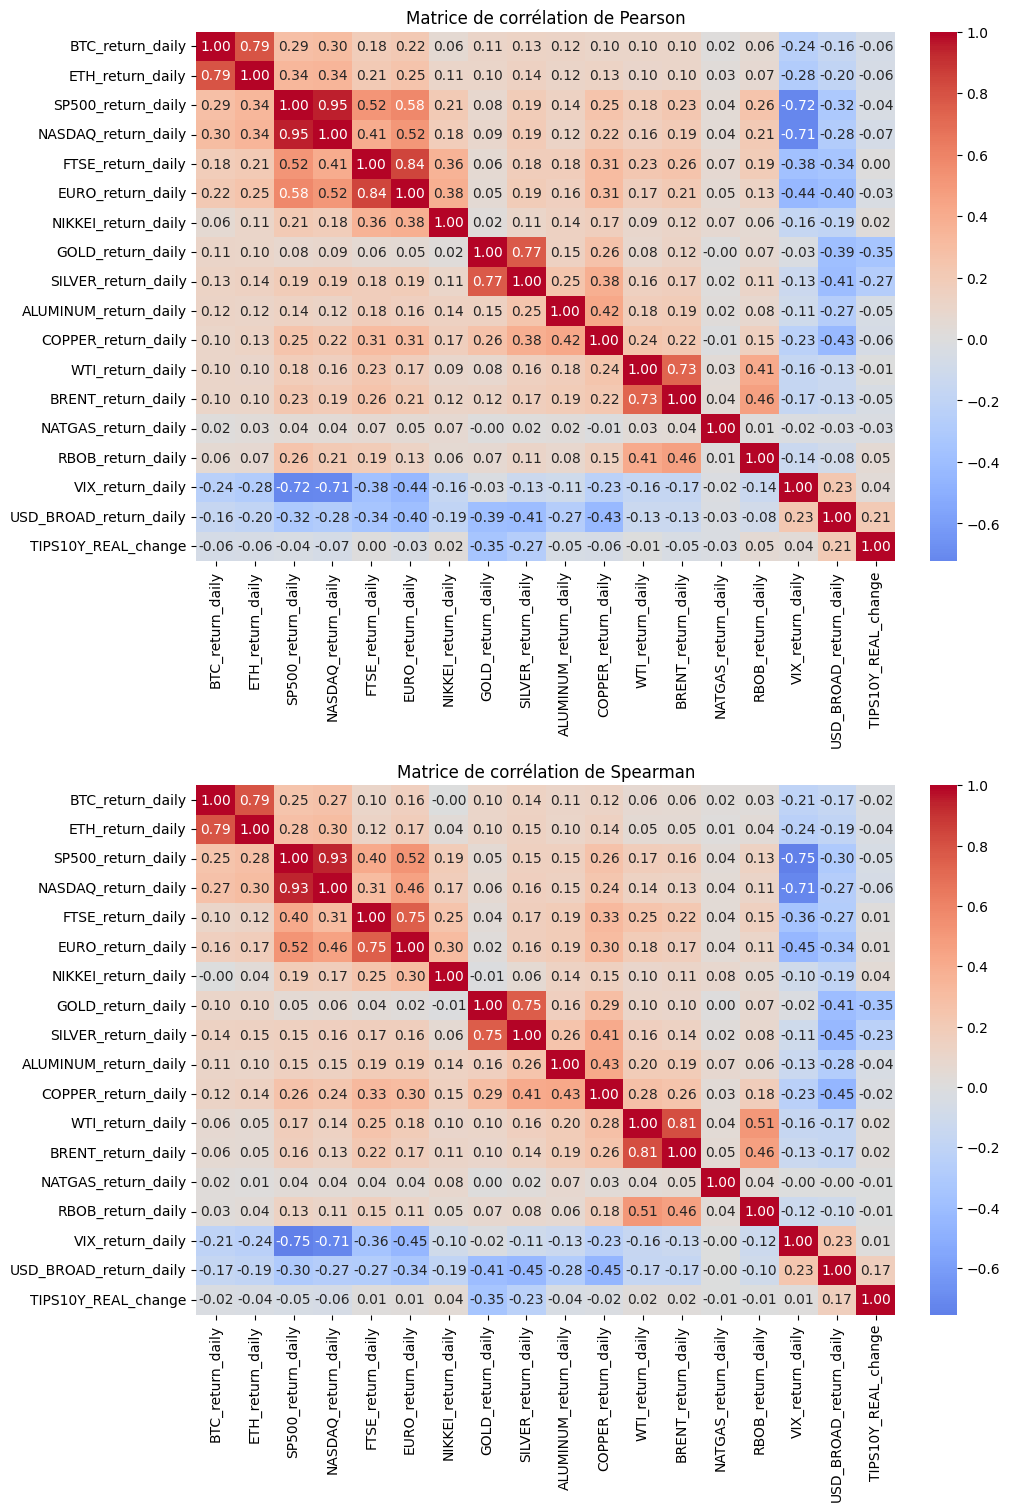

In [5]:
#-----Correlations-----


return_cols = [c for c in df.columns if c.endswith('_return_daily')]
change_cols = [c for c in df.columns if c.endswith('_change')]

cols_corr = return_cols + change_cols
df_corr = df[cols_corr].dropna()

pearson = df_corr.corr(method='pearson')
spearman = df_corr.corr(method='spearman')

fig, axes = plt.subplots(2, 1, figsize=(10, 15), constrained_layout=True)

sns.heatmap(pearson, annot=True, cmap="coolwarm", center=0, fmt=".2f", ax=axes[0])
axes[0].set_title("Matrice de corrélation de Pearson")

sns.heatmap(spearman, annot=True, cmap="coolwarm", center=0, fmt=".2f", ax=axes[1])
axes[1].set_title("Matrice de corrélation de Spearman")

plt.show()

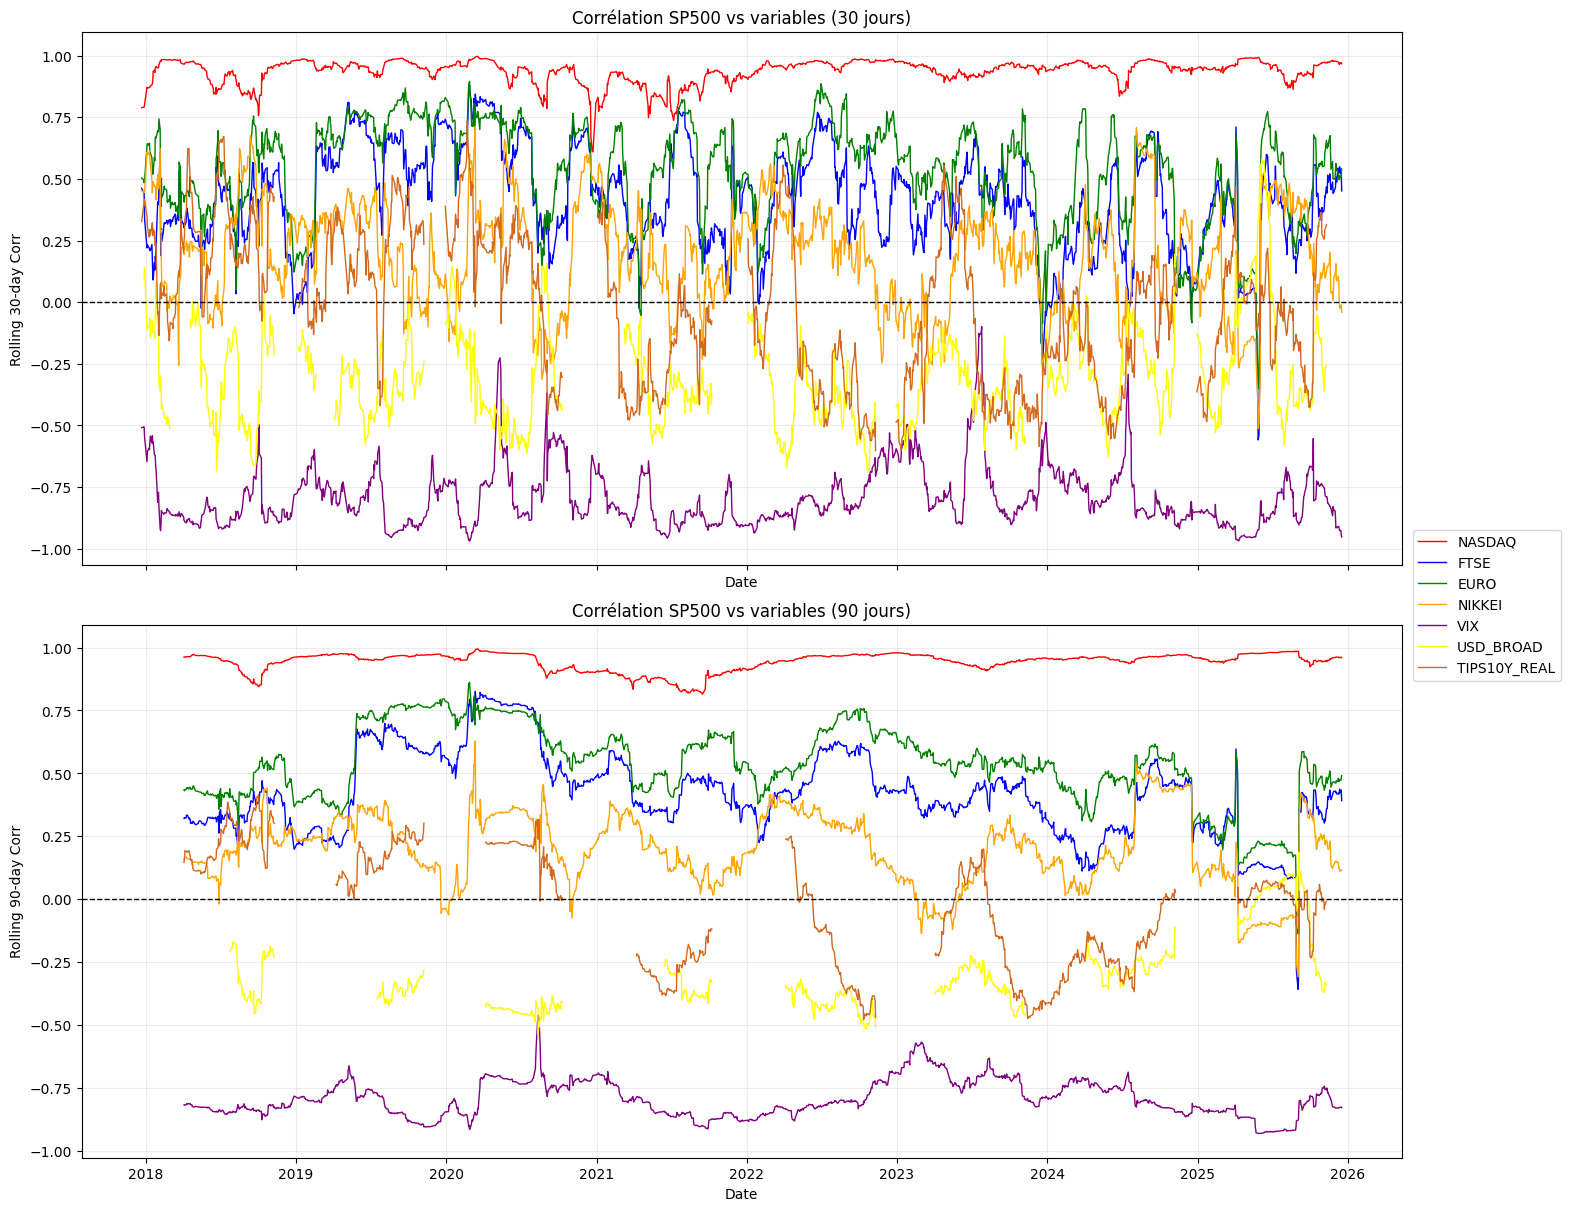

In [6]:
#-----Rollings-----


sp500_pairs = ['NASDAQ_return_daily', 'FTSE_return_daily', 'EURO_return_daily', 'NIKKEI_return_daily', 'VIX_return_daily', 
               'USD_BROAD_return_daily', 'TIPS10Y_REAL_change']

colors = {'NASDAQ_return_daily': 'red', 'FTSE_return_daily': 'blue', 'EURO_return_daily': 'green',
          'NIKKEI_return_daily': 'orange', 'VIX_return_daily': 'purple', 'USD_BROAD_return_daily': 'yellow',
          'TIPS10Y_REAL_change': 'chocolate'}

rolling_corr_sp500_30 = pd.DataFrame({'timestamp': df['timestamp']})
rolling_corr_sp500_90 = pd.DataFrame({'timestamp': df['timestamp']})

for col in sp500_pairs:
    rolling_corr_sp500_30[col] = df['SP500_return_daily'].rolling(30).corr(df[col])
    rolling_corr_sp500_90[col] = df['SP500_return_daily'].rolling(90).corr(df[col])

fig, axes = plt.subplots(2, 1, figsize=(14, 12), sharex=True, constrained_layout=True)

for col in sp500_pairs:
    axes[0].plot(rolling_corr_sp500_30['timestamp'], rolling_corr_sp500_30[col], color=colors[col], linewidth=1,
        label=col.replace('_return_daily', '').replace('_change', ''))
    axes[1].plot(rolling_corr_sp500_90['timestamp'], rolling_corr_sp500_90[col], color=colors[col], linewidth=1, 
        label=col.replace('_return_daily', '').replace('_change', ''))
    
axes[0].axhline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Rolling 30-day Corr')
axes[0].set_title('Corrélation SP500 vs variables (30 jours)')
axes[0].grid(True, alpha=0.25)

axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Rolling 90-day Corr')
axes[1].set_title('Corrélation SP500 vs variables (90 jours)')
axes[1].grid(True, alpha=0.25)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1, 0.5))

plt.show()

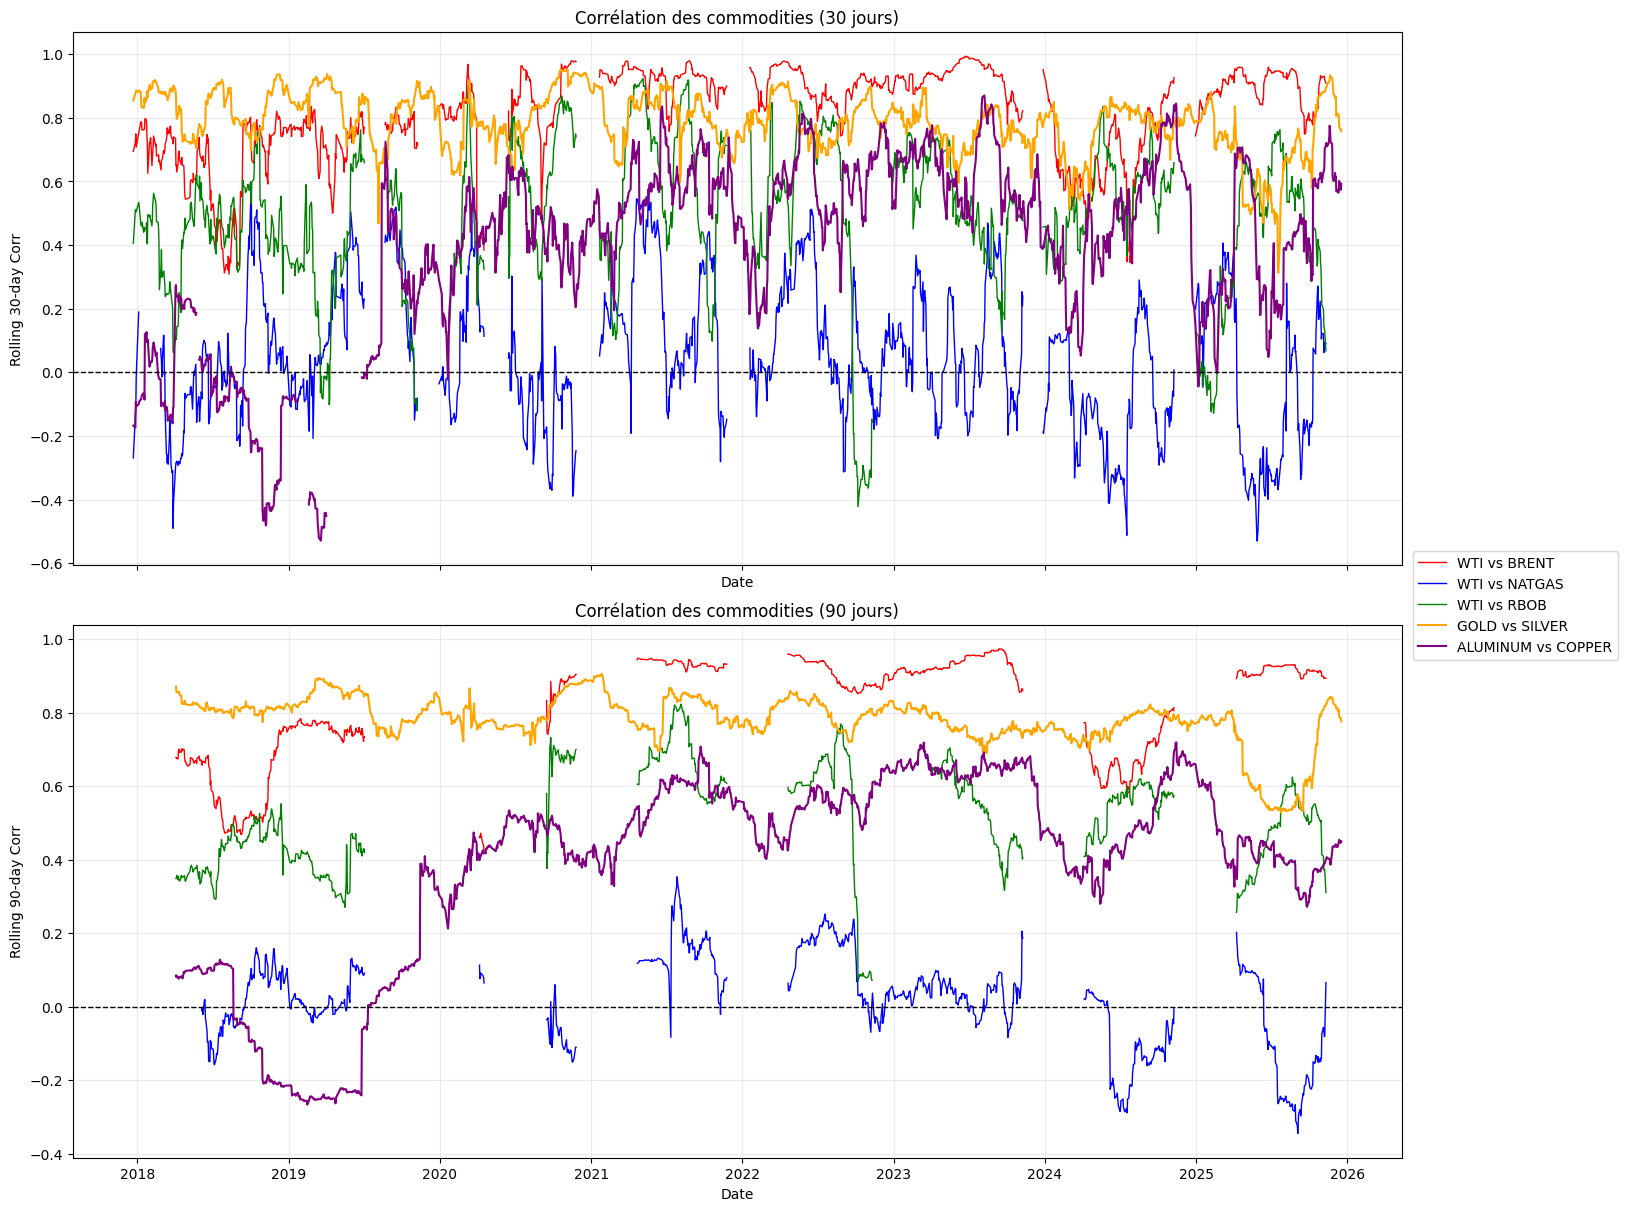

In [7]:
wti_pairs = ['BRENT_return_daily', 'NATGAS_return_daily', 'RBOB_return_daily']

colors = {'BRENT_return_daily': 'red', 'NATGAS_return_daily': 'blue', 'RBOB_return_daily': 'green'}

rolling_corr_wti_30 = pd.DataFrame({'timestamp': df['timestamp']})
rolling_corr_wti_90 = pd.DataFrame({'timestamp': df['timestamp']})

for col in wti_pairs:
    rolling_corr_wti_30[col] = df['WTI_return_daily'].rolling(30).corr(df[col])
    rolling_corr_wti_90[col] = df['WTI_return_daily'].rolling(90).corr(df[col])

rolling_corr_gold_30 = df['GOLD_return_daily'].rolling(window=30).corr(df['SILVER_return_daily'])
rolling_corr_gold_90 = df['GOLD_return_daily'].rolling(window=90).corr(df['SILVER_return_daily'])

rolling_corr_aluminium_30 = df['ALUMINUM_return_daily'].rolling(window=30).corr(df['COPPER_return_daily'])
rolling_corr_aluminium_90 = df['ALUMINUM_return_daily'].rolling(window=90).corr(df['COPPER_return_daily'])

fig, axes = plt.subplots(2, 1, figsize=(14, 12), sharex=True, constrained_layout=True)

for col in wti_pairs:
    axes[0].plot(rolling_corr_wti_30['timestamp'], rolling_corr_wti_30[col], color=colors[col], linewidth=1,
        label=f'WTI vs {col.replace('_return_daily', '')}')
    axes[1].plot(rolling_corr_wti_90['timestamp'], rolling_corr_wti_90[col], color=colors[col], linewidth=1, 
        label=f'WTI vs {col.replace('_return_daily', '')}')

axes[0].plot(df['timestamp'], rolling_corr_gold_30, label='GOLD vs SILVER', color='orange')
axes[0].plot(df['timestamp'], rolling_corr_aluminium_30, label='ALUMINUM vs COPPER', color='purple')

axes[1].plot(df['timestamp'], rolling_corr_gold_90, label='GOLD vs SILVER', color='orange')
axes[1].plot(df['timestamp'], rolling_corr_aluminium_90, label='ALUMINUM vs COPPER', color='purple')
    
axes[0].axhline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Rolling 30-day Corr')
axes[0].set_title('Corrélation des commodities (30 jours)')
axes[0].grid(True, alpha=0.25)

axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Rolling 90-day Corr')
axes[1].set_title('Corrélation des commodities (90 jours)')
axes[1].grid(True, alpha=0.25)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1, 0.5))

plt.show()

In [8]:
btc_pairs = ['ETH_return_daily', 'SP500_return_daily', 'NASDAQ_return_daily', 'FTSE_return_daily', 
             'EURO_return_daily', 'NIKKEI_return_daily', 'GOLD_return_daily', 'SILVER_return_daily', 'ALUMINUM_return_daily', 
             'COPPER_return_daily', 'WTI_return_daily', 'BRENT_return_daily', 'NATGAS_return_daily', 'RBOB_return_daily', 
             'VIX_return_daily', 'USD_BROAD_return_daily','TIPS10Y_REAL_change']

eth_pairs = ['BTC_return_daily', 'SP500_return_daily', 'NASDAQ_return_daily', 'FTSE_return_daily', 
             'EURO_return_daily', 'NIKKEI_return_daily', 'GOLD_return_daily', 'SILVER_return_daily', 'ALUMINUM_return_daily', 
             'COPPER_return_daily', 'WTI_return_daily', 'BRENT_return_daily', 'NATGAS_return_daily', 'RBOB_return_daily', 
             'VIX_return_daily', 'USD_BROAD_return_daily','TIPS10Y_REAL_change']

btc_rolling = pd.DataFrame({'timestamp': df['timestamp']})
eth_rolling = pd.DataFrame({'timestamp': df['timestamp']})

for p in btc_pairs:
    tmp = df[['BTC_return_daily', p]].dropna()
    btc_rolling[p] = tmp['BTC_return_daily'].rolling(90).corr(tmp[p])

for p in eth_pairs:
    tmp = df[['ETH_return_daily', p]].dropna()
    eth_rolling[p] = tmp['ETH_return_daily'].rolling(90).corr(tmp[p])

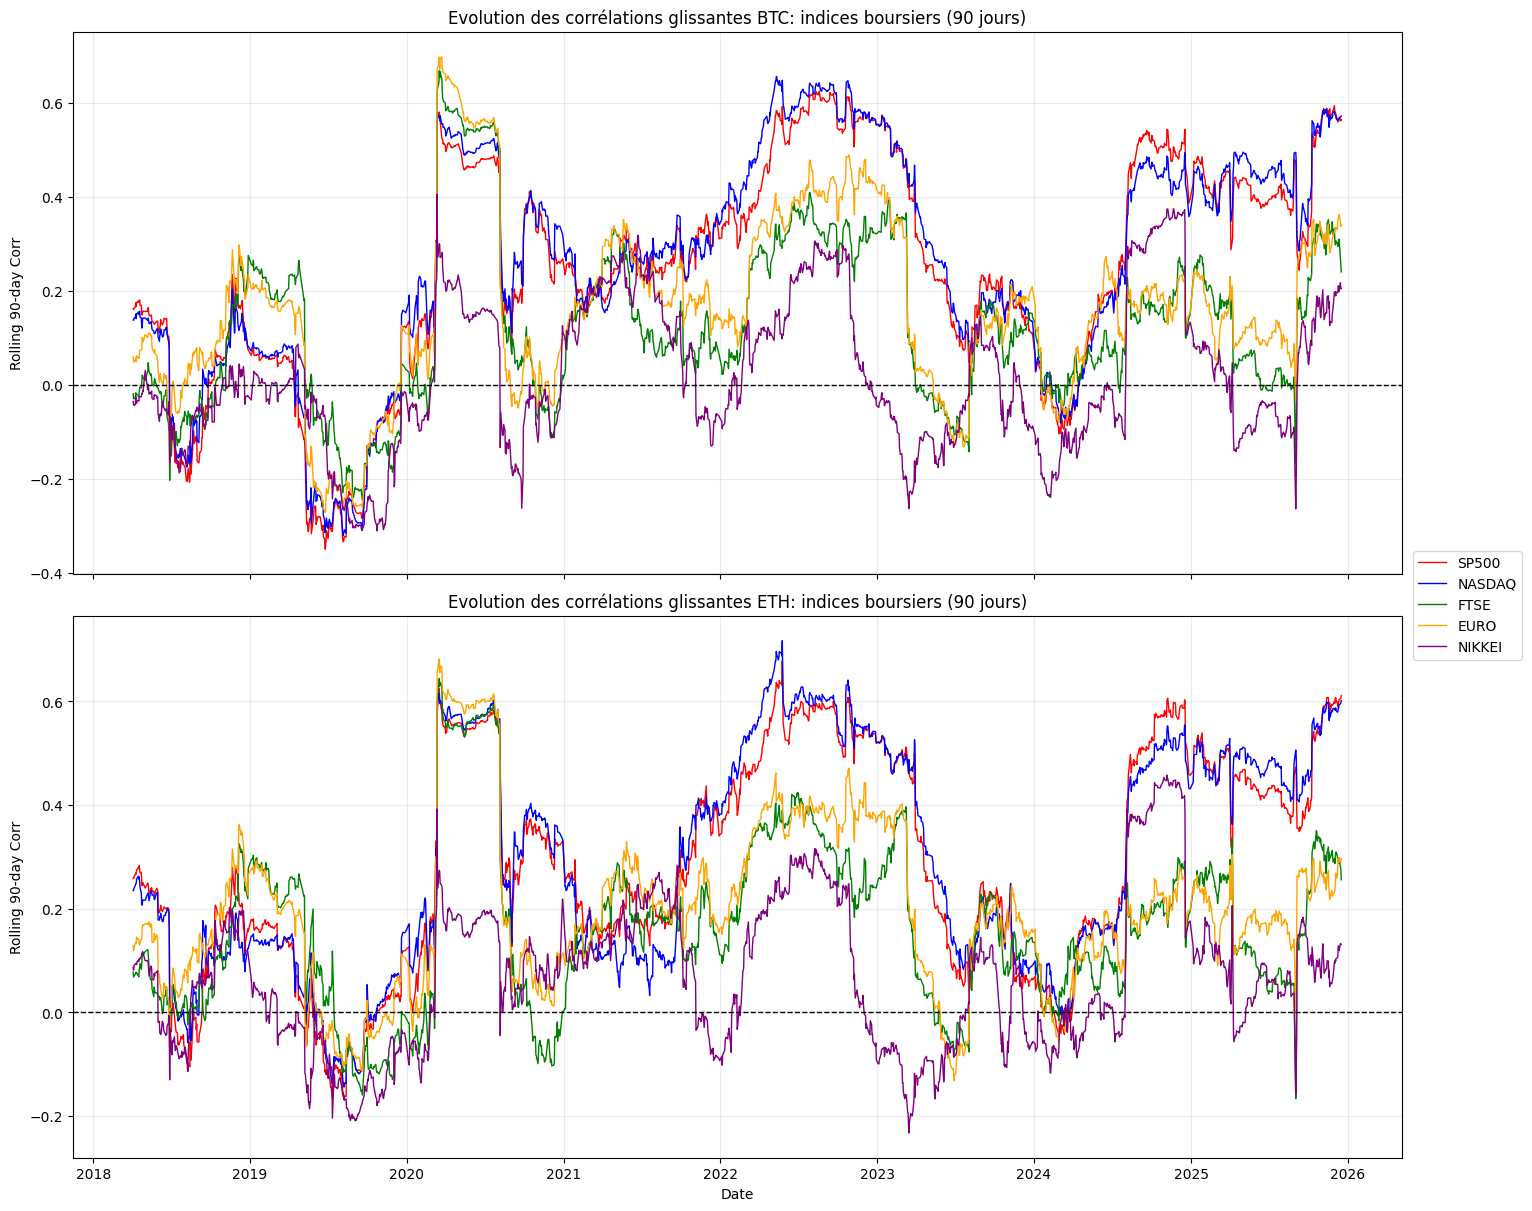

In [9]:
stock_markets = ['SP500_return_daily', 'NASDAQ_return_daily', 'FTSE_return_daily', 'EURO_return_daily', 'NIKKEI_return_daily']

colors = {'SP500_return_daily': 'red', 'NASDAQ_return_daily': 'blue', 'FTSE_return_daily': 'green',
          'EURO_return_daily': 'orange', 'NIKKEI_return_daily': 'purple'}

fig, axes = plt.subplots(2, 1, figsize=(14, 12), sharex=True, constrained_layout=True)

for col in stock_markets:
    axes[0].plot(btc_rolling['timestamp'], btc_rolling[col], color=colors[col], linewidth=1,
        label=col.replace('_return_daily', ''))
    axes[1].plot(eth_rolling['timestamp'], eth_rolling[col], color=colors[col], linewidth=1, 
        label=col.replace('_return_daily', ''))
    
axes[0].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_xlabel('Date')
axes[0].set_ylabel('Rolling 90-day Corr')
axes[0].set_title('Evolution des corrélations glissantes BTC: indices boursiers (90 jours)')
axes[0].grid(True, alpha=0.25)

axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Rolling 90-day Corr')
axes[1].set_title('Evolution des corrélations glissantes ETH: indices boursiers (90 jours)')
axes[1].grid(True, alpha=0.25)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1, 0.5))

plt.show()

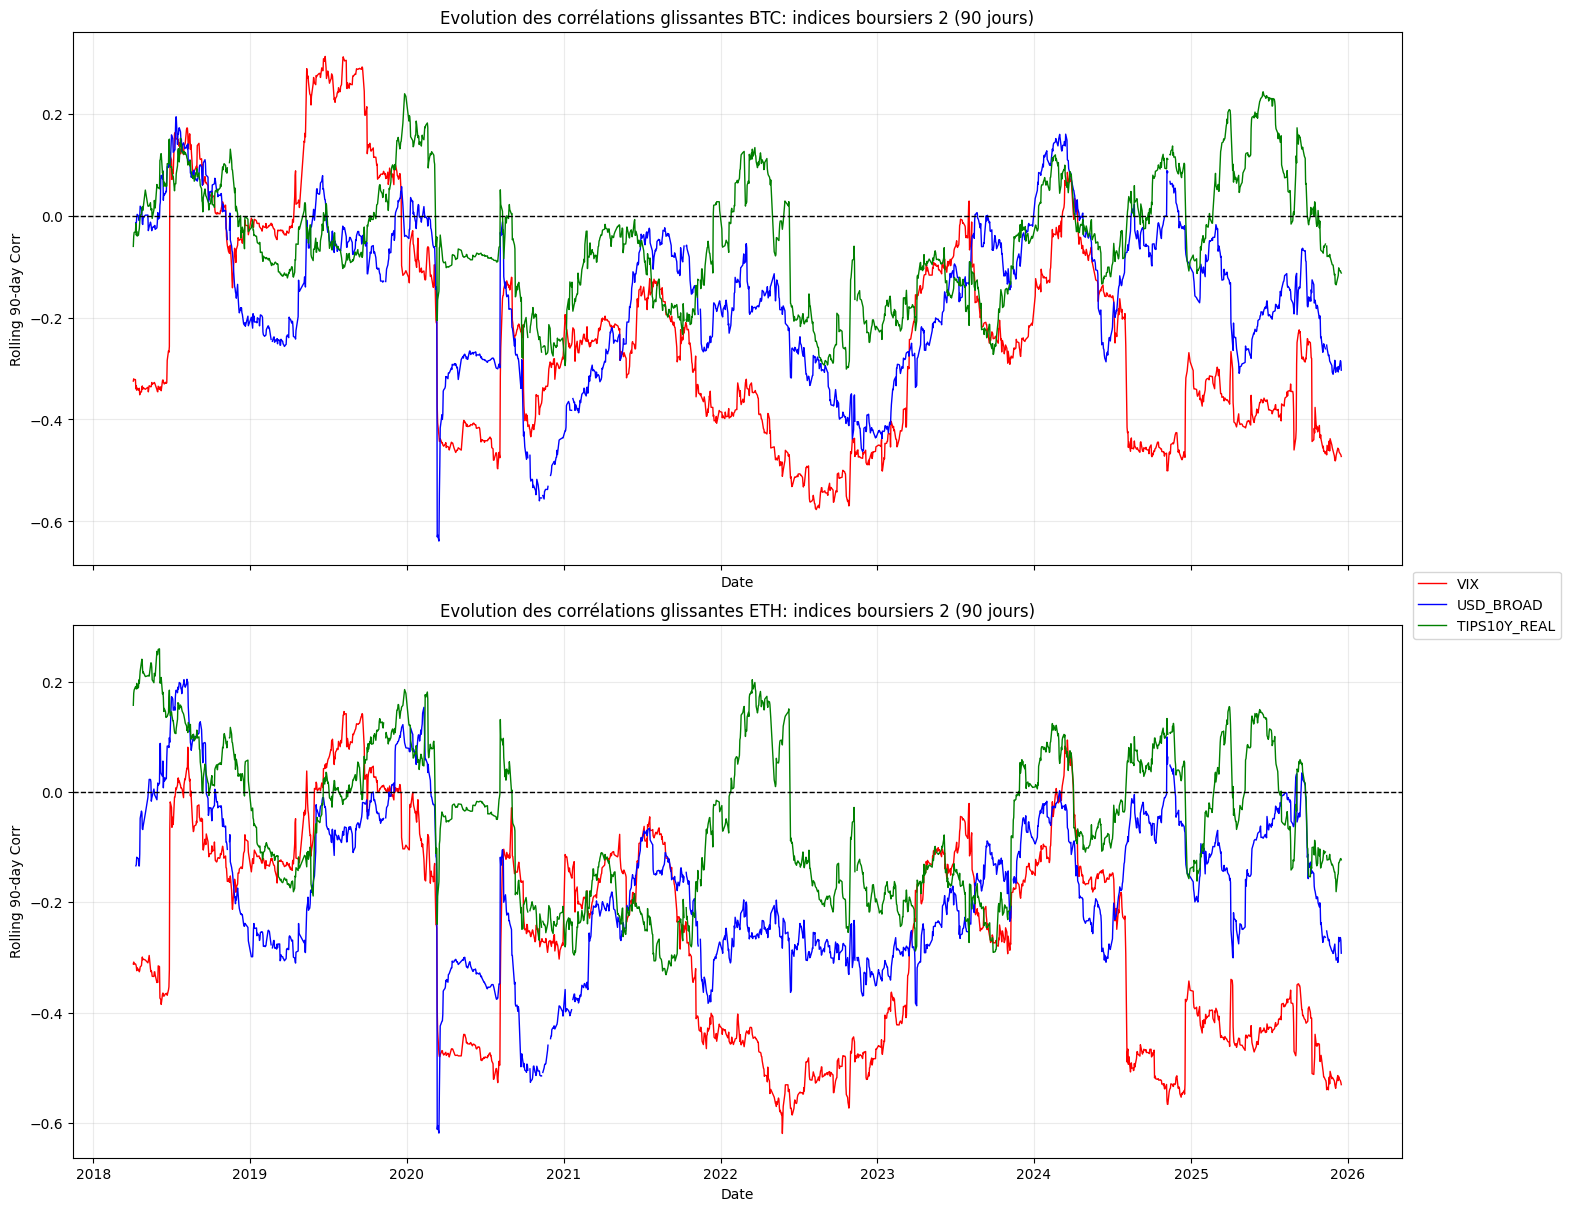

In [10]:
indices = ['VIX_return_daily', 'USD_BROAD_return_daily', 'TIPS10Y_REAL_change']

colors = {'VIX_return_daily': 'red', 'USD_BROAD_return_daily': 'blue', 'TIPS10Y_REAL_change': 'green'}

fig, axes = plt.subplots(2, 1, figsize=(14, 12), sharex=True, constrained_layout=True)

for col in indices:
    axes[0].plot(btc_rolling['timestamp'], btc_rolling[col], color=colors[col], linewidth=1,
        label=col.replace('_return_daily', '').replace('_change', ''))
    axes[1].plot(eth_rolling['timestamp'], eth_rolling[col], color=colors[col], linewidth=1, 
        label=col.replace('_return_daily', '').replace('_change', ''))
    
axes[0].axhline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Rolling 90-day Corr')
axes[0].set_title('Evolution des corrélations glissantes BTC: indices boursiers 2 (90 jours)')
axes[0].grid(True, alpha=0.25)

axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Rolling 90-day Corr')
axes[1].set_title('Evolution des corrélations glissantes ETH: indices boursiers 2 (90 jours)')
axes[1].grid(True, alpha=0.25)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1, 0.5))

plt.show()

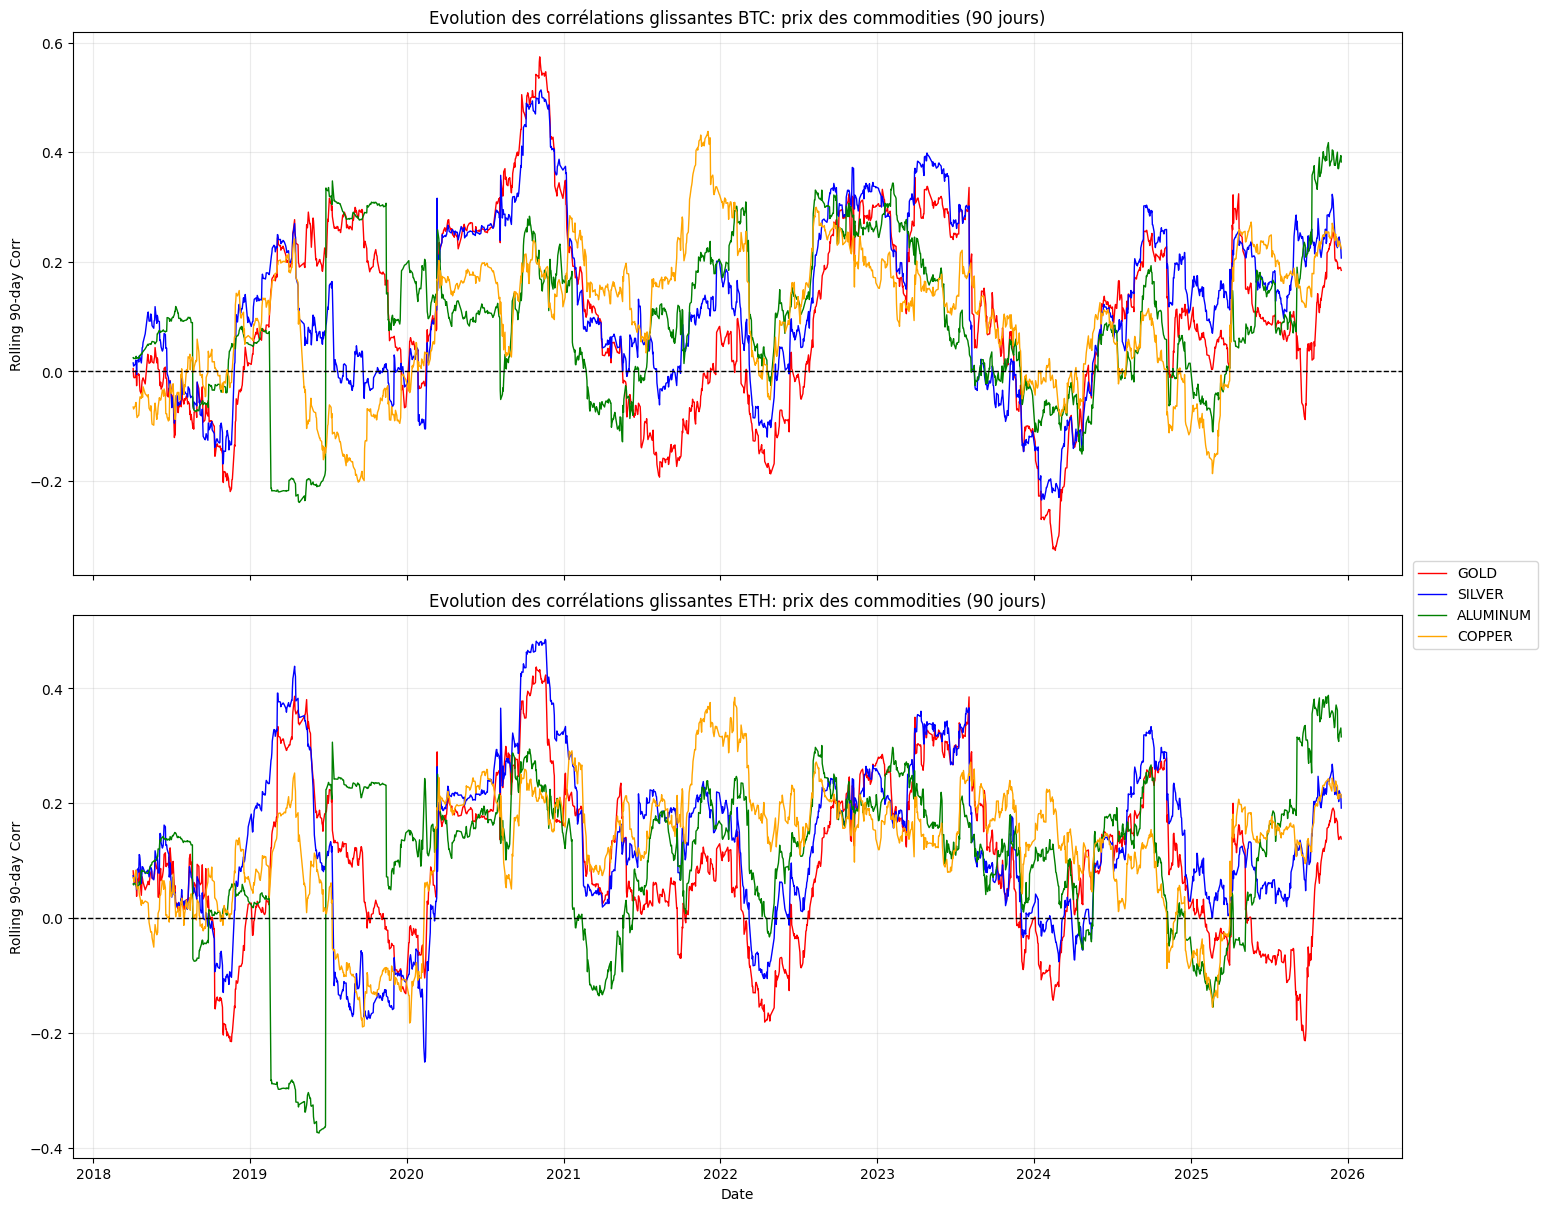

In [11]:
commodities = ['GOLD_return_daily', 'SILVER_return_daily', 'ALUMINUM_return_daily', 'COPPER_return_daily']

colors = {'GOLD_return_daily': 'red', 'SILVER_return_daily': 'blue', 'ALUMINUM_return_daily': 'green',
          'COPPER_return_daily': 'orange'}

fig, axes = plt.subplots(2, 1, figsize=(14, 12), sharex=True, constrained_layout=True)

for col in commodities:
    axes[0].plot(btc_rolling['timestamp'], btc_rolling[col], color=colors[col], linewidth=1,
        label=col.replace('_return_daily', ''))
    axes[1].plot(eth_rolling['timestamp'], eth_rolling[col], color=colors[col], linewidth=1, 
        label=col.replace('_return_daily', ''))
    
axes[0].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_xlabel('Date')
axes[0].set_ylabel('Rolling 90-day Corr')
axes[0].set_title('Evolution des corrélations glissantes BTC: prix des commodities (90 jours)')
axes[0].grid(True, alpha=0.25)

axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Rolling 90-day Corr')
axes[1].set_title('Evolution des corrélations glissantes ETH: prix des commodities (90 jours)')
axes[1].grid(True, alpha=0.25)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1, 0.5))

plt.show()

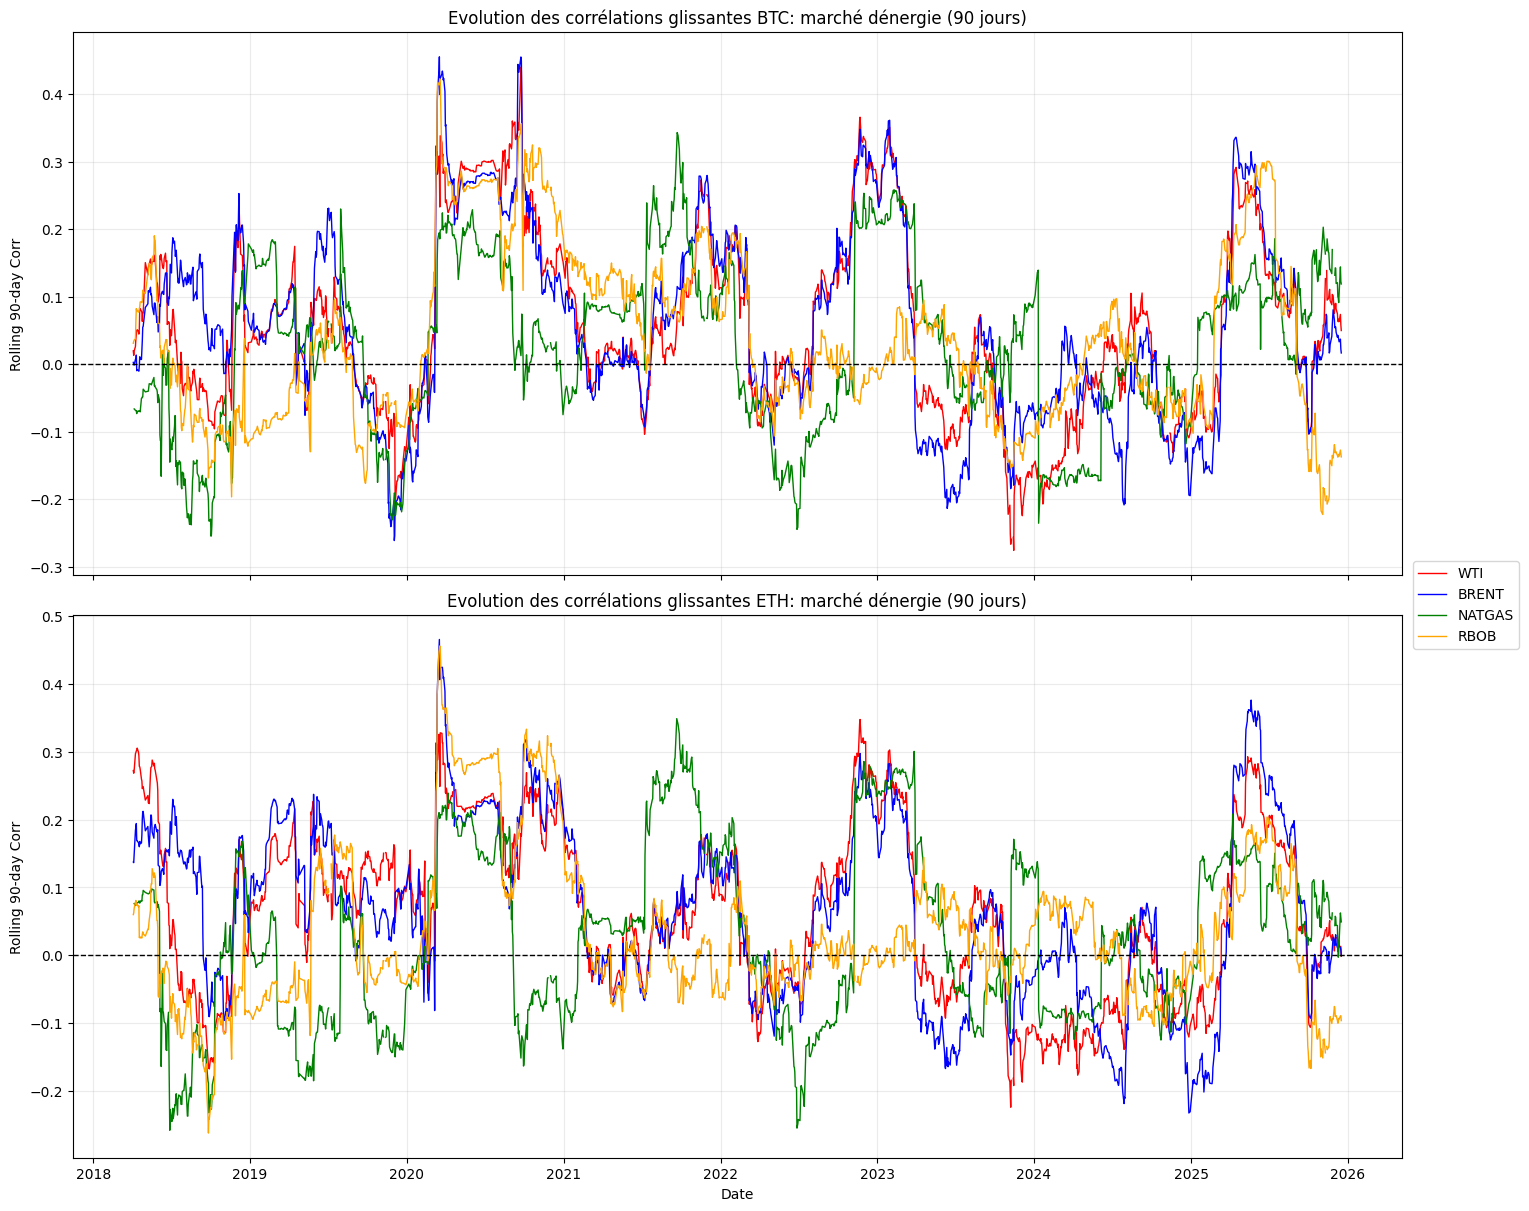

In [12]:
energy_markets = ['WTI_return_daily', 'BRENT_return_daily', 'NATGAS_return_daily', 'RBOB_return_daily']

colors = {'WTI_return_daily': 'red', 'BRENT_return_daily': 'blue', 'NATGAS_return_daily': 'green',
          'RBOB_return_daily': 'orange'}

fig, axes = plt.subplots(2, 1, figsize=(14, 12), sharex=True, constrained_layout=True)

for col in energy_markets:
    axes[0].plot(btc_rolling['timestamp'], btc_rolling[col], color=colors[col], linewidth=1,
        label=col.replace('_return_daily', ''))
    axes[1].plot(eth_rolling['timestamp'], eth_rolling[col], color=colors[col], linewidth=1, 
        label=col.replace('_return_daily', ''))
    
axes[0].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_xlabel('Date')
axes[0].set_ylabel('Rolling 90-day Corr')
axes[0].set_title('Evolution des corrélations glissantes BTC: marché dénergie (90 jours)')
axes[0].grid(True, alpha=0.25)

axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Rolling 90-day Corr')
axes[1].set_title('Evolution des corrélations glissantes ETH: marché dénergie (90 jours)')
axes[1].grid(True, alpha=0.25)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1, 0.5))

plt.show()

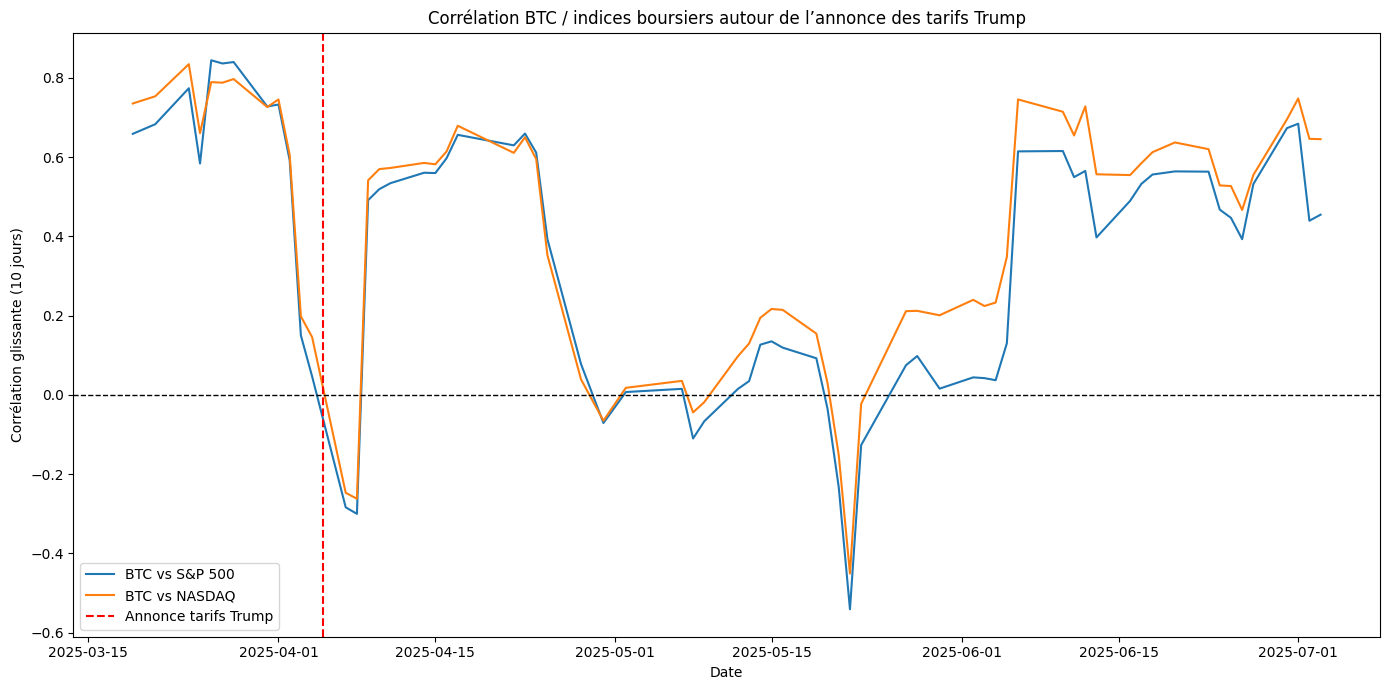

In [15]:
# Date de l'événement macroéconomique
event_date = pd.to_datetime("2025-04-05")

# Fenêtre autour de l'événement (-15 jours avant l'événement et 60 jours après)
start_date = event_date - pd.Timedelta(days=15)
end_date = event_date + pd.Timedelta(days=60)

# Sous-échantillon autour de l'événement
event_df = df_final[
    (df_final["timestamp"] >= start_date) &
    (df_final["timestamp"] <= end_date)
].copy()

# Taille de la corrélation glissante (court terme)
rolling_window = 10

indices = {
    "SP500": "S&P 500",
    "NASDAQ": "NASDAQ"
}

plt.figure(figsize=(14, 7))

for idx_code, idx_name in indices.items():
    rolling_corr = (
        event_df["BTC_return_daily"]
        .rolling(window=rolling_window)
        .corr(event_df[f"{idx_code}_return_daily"])
    )

    plt.plot(
        event_df["timestamp"],
        rolling_corr,
        label=f"BTC vs {idx_name}"
    )

# Références graphiques
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.axvline(event_date, color="red", linestyle="--", label="Annonce tarifs Trump")

plt.xlabel("Date")
plt.ylabel("Corrélation glissante (10 jours)")
plt.title("Corrélation BTC: indices boursiers autour de l’annonce des tarifs Trump")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Date de l'annonce majeure du COVID-19
event_date = pd.to_datetime('2020-03-11')

# On analyse la période 90 jours avant et après l’événement
start_date = event_date - pd.Timedelta(days=90)
end_date = event_date + pd.Timedelta(days=90)

# Filtrer le dataset
event_df = df_final[(df_final['timestamp'] >= start_date) & (df_final['timestamp'] <= end_date)]

# Liste des indices pour calcul de corrélation avec BTC
indices = {
    "SP500": "S&P 500",
    "NASDAQ": "NASDAQ",
    "FTSE": "FTSE 100",
    "EURO": "EURO STOXX 50",
    "NIKKEI": "Nikkei 225"
}

# Calcul des corrélations glissantes (rolling 30 jours)
rolling_corr = {}
for idx in indices:
    rolling_corr[idx] = event_df['BTC_return_daily'].rolling(window=30).corr(event_df[f'{idx}_return_daily'])

# Visualisation
plt.figure(figsize=(14,7))
colors = ['blue', 'green', 'red', 'purple', 'orange']
for i, idx in enumerate(indices):
    plt.plot(event_df['timestamp'], rolling_corr[idx], label=f'BTC vs {idx}', color=colors[i])

plt.axhline(0, color='black', linestyle='--')
plt.axvline(event_date, color='red', linestyle='--', label='Déclaration OMS COVID-19')
plt.xlabel('Date')
plt.ylabel('Corrélation glissante 10 jours')
plt.title('Évolution de la corrélation BTC / Indices boursiers autour du choc COVID-19')
plt.legend()
plt.show()

In [ ]:
# Définir la période : second semestre 2025
start_date = pd.to_datetime("2025-06-01")
end_date = pd.to_datetime("2025-12-23")

df_2025 = df_final[
    (df_final["timestamp"] >= start_date) &
    (df_final["timestamp"] <= end_date)
].copy()

# Calcul des performances cumulées (base 100)
assets = {
    "Bitcoin": "BTC_price",
    "S&P 500": "SP500_price",
    "NASDAQ": "NASDAQ_price",
}

for name, col in assets.items():
    df_2025[name] = 100 * df_2025[col] / df_2025[col].iloc[0]

# Graphique
plt.figure(figsize=(12,6))

for name in assets.keys():
    plt.plot(df_2025["timestamp"], df_2025[name], label=name)

plt.axhline(100, color="black", linestyle="--", linewidth=0.8)
plt.title("Trajectoires comparées de Bitcoin et des actions américaines\nSecond semestre 2025 (base 100)")
plt.xlabel("Date")
plt.ylabel("Indice de performance (base 100)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# Définir le début de la période (mi-2024)
start_date = pd.to_datetime('2024-06-01')
df_recent = df_final[df_final['timestamp'] >= start_date].reset_index(drop=True)

# Calcul des corrélations glissantes sur 90 jours
rolling_corr_SP500 = df_recent['BTC_return_daily'].rolling(window=90).corr(df_recent['SP500_return_daily'])
rolling_corr_NASDAQ = df_recent['BTC_return_daily'].rolling(window=90).corr(df_recent['NASDAQ_return_daily'])
rolling_corr_FTSE = df_recent['BTC_return_daily'].rolling(window=90).corr(df_recent['FTSE_return_daily'])
rolling_corr_EURO = df_recent['BTC_return_daily'].rolling(window=90).corr(df_recent['EURO_return_daily'])
rolling_corr_NIKKEI = df_recent['BTC_return_daily'].rolling(window=90).corr(df_recent['NIKKEI_return_daily'])

# Tracer toutes les corrélations sur le même graphique
plt.figure(figsize=(14,7))
plt.plot(df_recent['timestamp'], rolling_corr_SP500, label='BTC vs SP500')
plt.plot(df_recent['timestamp'], rolling_corr_NASDAQ, label='BTC vs NASDAQ')
plt.plot(df_recent['timestamp'], rolling_corr_FTSE, label='BTC vs FTSE100')
plt.plot(df_recent['timestamp'], rolling_corr_EURO, label='BTC vs EURO STOXX 50')
plt.plot(df_recent['timestamp'], rolling_corr_NIKKEI, label='BTC vs Nikkei 225')

plt.axhline(0, color='black', linestyle='--')
plt.xlabel('Date')
plt.ylabel('Rolling 90-day Correlation')
plt.title('Evolution des corrélations glissantes BTC / Indices boursiers (90 jours) depuis mi-2024')
plt.legend()
plt.show()

In [ ]:
tmp = df[['BTC_return_daily', 'NASDAQ_return_daily', 'VIX']].dropna()

q_low, q_high = tmp['VIX'].quantile([0.25, 0.75])

corr_low_vix  = tmp[tmp['VIX'] <= q_low][['BTC_return_daily', 'NASDAQ_return_daily']].corr().iloc[0,1]
corr_high_vix = tmp[tmp['VIX'] >= q_high][['BTC_return_daily', 'NASDAQ_return_daily']].corr().iloc[0,1]

print("Corr BTC-NASDAQ (VIX baixo):", corr_low_vix)
print("Corr BTC-NASDAQ (VIX alto):", corr_high_vix)

In [ ]:
def lag_corr(df_in, x, y, max_lag=10):
    out = {}
    for k in range(-max_lag, max_lag + 1):
        if k < 0:
            # x no futuro vs y hoje
            out[k] = df_in[x].shift(-k).corr(df_in[y])
        else:
            # x hoje vs y no passado
            out[k] = df_in[x].corr(df_in[y].shift(k))
    return pd.Series(out).sort_index()

tmp = df[['BTC_return_daily', 'NASDAQ_return_daily']].dropna()
lags = lag_corr(tmp, 'BTC_return_daily', 'NASDAQ_return_daily', max_lag=10)

print(lags)

In [18]:
import os
print(os.getcwd())

/home/onyxia/work
